# 라이브러리 가져오기

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings(action='ignore')

# 데이터 가져오기

In [2]:
bike_pd = pd.read_csv('./data/bike_train.csv', encoding='euc-kr')

In [3]:
bike_pd.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [4]:
bike_pd.describe()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
count,10886.000000,10886.000000,10886.000000,10886.000000,10886.00000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000
mean,2.506614,0.028569,0.680875,1.418427,20.23086,23.655084,61.886460,12.799395,36.021955,155.552177,191.574132
std,1.116174,0.166599,0.466159,0.633839,7.79159,8.474601,19.245033,8.164537,49.960477,151.039033,181.144454
min,1.000000,0.000000,0.000000,1.000000,0.82000,0.760000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,0.000000,0.000000,1.000000,13.94000,16.665000,47.000000,7.001500,4.000000,36.000000,42.000000
50%,3.000000,0.000000,1.000000,1.000000,20.50000,24.240000,62.000000,12.998000,17.000000,118.000000,145.000000
75%,4.000000,0.000000,1.000000,2.000000,26.24000,31.060000,77.000000,16.997900,49.000000,222.000000,284.000000
max,4.000000,1.000000,1.000000,4.000000,41.00000,45.455000,100.000000,56.996900,367.000000,886.000000,977.000000


# datetime 전처리

In [5]:
bike_pd['datetime'] = pd.to_datetime(bike_pd['datetime'])

bike_pd['year'] = bike_pd['datetime'].dt.year
bike_pd['month'] = bike_pd['datetime'].dt.month
bike_pd['day'] = bike_pd['datetime'].dt.day
bike_pd['hour'] = bike_pd['datetime'].dt.hour
bike_pd['dayofweek'] = bike_pd['datetime'].dt.dayofweek
bike_pd['is_weekend'] = (bike_pd['dayofweek'] >= 5).astype(int)

In [6]:
X = bike_pd.drop(columns=['datetime', 'casual', 'registered', 'count'])
y = bike_pd['count']

# 데이터 확인

In [7]:
bike_pd.info()
bike_pd.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 18 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   datetime    10886 non-null  datetime64[us]
 1   season      10886 non-null  int64         
 2   holiday     10886 non-null  int64         
 3   workingday  10886 non-null  int64         
 4   weather     10886 non-null  int64         
 5   temp        10886 non-null  float64       
 6   atemp       10886 non-null  float64       
 7   humidity    10886 non-null  int64         
 8   windspeed   10886 non-null  float64       
 9   casual      10886 non-null  int64         
 10  registered  10886 non-null  int64         
 11  count       10886 non-null  int64         
 12  year        10886 non-null  int32         
 13  month       10886 non-null  int32         
 14  day         10886 non-null  int32         
 15  hour        10886 non-null  int32         
 16  dayofweek   10886 non-null  int32

datetime      0
season        0
holiday       0
workingday    0
weather       0
temp          0
atemp         0
humidity      0
windspeed     0
casual        0
registered    0
count         0
year          0
month         0
day           0
hour          0
dayofweek     0
is_weekend    0
dtype: int64

# Train/Test 분리

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

# 랜덤포레스트

In [13]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
from sklearn.metrics import r2_score

# 모델 학습
rf = RandomForestRegressor(random_state=0)
rf.fit(X_train, y_train)

# 예측
y_pred = rf.predict(X_test)

# 평가
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", round(mae, 4))
print("RMSE:", round(rmse, 4))
print("R2:", round(r2, 4))

MAE: 47.2962
RMSE: 74.062
R2: 0.8842


In [15]:
feature_importance = pd.Series(rf.feature_importances_, index=X_train.columns)
feature_importance.sort_values(ascending=False)

hour          0.590672
atemp         0.105120
year          0.068241
temp          0.056575
workingday    0.034668
dayofweek     0.033307
humidity      0.029300
month         0.025097
weather       0.015622
is_weekend    0.013694
day           0.010083
windspeed     0.008931
season        0.006642
holiday       0.002047
dtype: float64

In [17]:
y_log = np.log1p(bike_pd['count'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y_log, test_size=0.2, shuffle=False
)

rf = RandomForestRegressor(random_state=0)
rf.fit(X_train, y_train)

y_pred_log = rf.predict(X_test)
y_pred = np.expm1(y_pred_log)
y_true = np.expm1(y_test)

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

print("MAE:", round(mae, 4))
print("RMSE:", round(rmse, 4))
print("R2:", round(r2, 4))

MAE: 57.3109
RMSE: 91.6077
R2: 0.8228


랜덤포레스트 회귀모델을 적용한 결과, 테스트 데이터 기준 MAE는 47.30, RMSE는 74.06으로 나타났다. <br>이는 평균적으로 약 47대 수준의 예측 오차가 발생함을 의미한다. <br>초기 베이스라인 모델로는 수요 패턴을 어느 정도 포착한 것으로 볼 수 있으나, <br>특정 구간에서 큰 오차가 존재하여 추가적인 변수 가공과 하이퍼파라미터 튜닝이 필요하다.

In [19]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = bike_pd.copy()

# datetime 파생
df['datetime'] = pd.to_datetime(df['datetime'])
df['year'] = df['datetime'].dt.year
df['month'] = df['datetime'].dt.month
df['day'] = df['datetime'].dt.day
df['hour'] = df['datetime'].dt.hour
df['dayofweek'] = df['datetime'].dt.dayofweek
df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)

# 사이클릭 인코딩 (핵심)
df['hour_sin'] = np.sin(2*np.pi*df['hour']/24)
df['hour_cos'] = np.cos(2*np.pi*df['hour']/24)
df['month_sin'] = np.sin(2*np.pi*df['month']/12)
df['month_cos'] = np.cos(2*np.pi*df['month']/12)

# X, y (누수 방지)
X = df.drop(columns=['datetime','count','casual','registered','hour','month'])
y = df['count']

# 범주형/수치형 분리
cat_cols = ['season', 'holiday', 'workingday', 'weather', 'dayofweek', 'is_weekend']
num_cols = [c for c in X.columns if c not in cat_cols]

# OneHotEncoder 버전 호환
try:
    ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown='ignore', sparse=False)

preprocess = ColumnTransformer(
    transformers=[
        ('cat', ohe, cat_cols),
        ('num', 'passthrough', num_cols)
    ],
    remainder='drop'
)

model = RandomForestRegressor(
  n_estimators=600,
  random_state=0,
  min_samples_leaf=2,
  max_features='sqrt',
  n_jobs=-1
)

# n_init은 RF에 원래 없음 (환경에 따라 위 라인 오류날 수 있어서 안전하게 처리)
params = model.get_params()
if params.get('n_init', None) is not None:
    model.set_params(n_init=10)

pipe = Pipeline([
    ('prep', preprocess),
    ('rf', model)
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

pipe.fit(X_train, y_train)
pred = pipe.predict(X_test)

mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print("MAE:", round(mae, 4))
print("RMSE:", round(rmse, 4))
print("R2:", round(r2, 4))

MAE: 85.5667
RMSE: 122.2661
R2: 0.6843


In [20]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = bike_pd.copy()
df['datetime'] = pd.to_datetime(df['datetime'])

df['year'] = df['datetime'].dt.year
df['month'] = df['datetime'].dt.month
df['day'] = df['datetime'].dt.day
df['hour'] = df['datetime'].dt.hour
df['dayofweek'] = df['datetime'].dt.dayofweek
df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)

# ✅ sin/cos는 "추가"만
df['hour_sin'] = np.sin(2*np.pi*df['hour']/24)
df['hour_cos'] = np.cos(2*np.pi*df['hour']/24)
df['month_sin'] = np.sin(2*np.pi*df['month']/12)
df['month_cos'] = np.cos(2*np.pi*df['month']/12)

# ✅ 누수 제거
X = df.drop(columns=['datetime','count','casual','registered'])
y = df['count']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

rf = RandomForestRegressor(
    n_estimators=600,
    random_state=0,
    max_features=1.0,      # ✅ 일단 기본(전체)로 회복
    min_samples_leaf=1,    # ✅ 언더핏 방지
    n_jobs=-1
)
rf.fit(X_train, y_train)
pred = rf.predict(X_test)

mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print("MAE:", round(mae, 4))
print("RMSE:", round(rmse, 4))
print("R2:", round(r2, 4))

MAE: 51.8132
RMSE: 78.516
R2: 0.8698


시간 파생변수와 주기성 변수를 추가한 랜덤포레스트 모델의 설명력은 R² 0.8698로 높게 나타났다. <br>다만 초기 베이스라인 모델과 비교했을 때 MAE와 RMSE는 소폭 악화되어, <br>본 데이터에서는 복잡한 파생변수 추가보다 기본 시간 변수(hour) 자체가 예측에 더 직접적으로 기여하는 것으로 판단된다.

# 랜덤포레스트 하이퍼파라미터 튜닝

In [22]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 랜덤포레스트 모델
rf = RandomForestRegressor(random_state=0, n_jobs=-1)

# 하이퍼파라미터 후보
param_grid = {
    'n_estimators': [200, 400],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2', None]
}

# 시계열 분할
tscv = TimeSeriesSplit(n_splits=5)

# GridSearchCV
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=tscv,
    scoring='neg_mean_absolute_error',   # MAE 기준으로 최적화
    n_jobs=-1,
    verbose=2
)

# 학습
grid_search.fit(X_train, y_train)

# 최적 파라미터 확인
print("Best Params:", grid_search.best_params_)
print("Best CV Score (MAE):", -grid_search.best_score_)

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best Params: {'max_depth': 20, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 400}
Best CV Score (MAE): 51.38177078642823


In [23]:
best_rf = grid_search.best_estimator_

y_pred = best_rf.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Test MAE:", round(mae, 4))
print("Test RMSE:", round(rmse, 4))
print("Test R2:", round(r2, 4))

Test MAE: 52.1299
Test RMSE: 79.1224
Test R2: 0.8678


# HGB 회귀모델

In [24]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

hgb = HistGradientBoostingRegressor(
    learning_rate=0.05,
    max_depth=10,
    max_iter=500,
    random_state=0
)

hgb.fit(X_train, y_train)
pred = hgb.predict(X_test)

mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print("HGB MAE:", round(mae, 4))
print("HGB RMSE:", round(rmse, 4))
print("HGB R2:", round(r2, 4))

HGB MAE: 38.6902
HGB RMSE: 58.8383
HGB R2: 0.9269


RandomForestRegressor와 비교한 결과, HistGradientBoostingRegressor가 더 우수한 예측 성능을 보였다. <br>테스트셋 기준 MAE는 38.69, RMSE는 58.84, R²는 0.9269로 나타났으며, <br>이는 시간대 및 기상 변수 간의 비선형 관계를 보다 효과적으로 학습한 결과로 해석된다.

# HGB 하이퍼파라미터 튜닝

In [25]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 시계열 분할
tscv = TimeSeriesSplit(n_splits=5)

# 모델
hgb = HistGradientBoostingRegressor(random_state=0)

# 하이퍼파라미터 후보
param_grid = {
    'learning_rate': [0.03, 0.05, 0.1],
    'max_iter': [200, 500, 800],
    'max_depth': [5, 10, None],
    'min_samples_leaf': [10, 20, 30],
    'l2_regularization': [0.0, 0.1, 1.0],
    'max_bins': [255]
}

# GridSearchCV
grid_search = GridSearchCV(
    estimator=hgb,
    param_grid=param_grid,
    cv=tscv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=2
)

# 학습
grid_search.fit(X_train, y_train)

# 최적 파라미터
print("Best Params:", grid_search.best_params_)
print("Best CV Score (MAE):", -grid_search.best_score_)

# 최적 모델
best_hgb = grid_search.best_estimator_

# 테스트 평가
y_pred = best_hgb.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Test MAE:", round(mae, 4))
print("Test RMSE:", round(rmse, 4))
print("Test R2:", round(r2, 4))

Fitting 5 folds for each of 243 candidates, totalling 1215 fits
Best Params: {'l2_regularization': 0.0, 'learning_rate': 0.1, 'max_bins': 255, 'max_depth': 5, 'max_iter': 800, 'min_samples_leaf': 20}
Best CV Score (MAE): 45.57822901353213
Test MAE: 41.7477
Test RMSE: 63.3244
Test R2: 0.9153


# 엑스트라 트리 회귀 모델

In [26]:
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

etr = ExtraTreesRegressor(
    n_estimators=800,
    random_state=0,
    n_jobs=-1,
    min_samples_leaf=1
)

etr.fit(X_train, y_train)
pred = etr.predict(X_test)

mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print("ETR MAE:", round(mae, 4))
print("ETR RMSE:", round(rmse, 4))
print("ETR R2:", round(r2, 4))

ETR MAE: 48.9176
ETR RMSE: 75.0656
ETR R2: 0.881


# GBM 활용

In [27]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(
    random_state=0,
    learning_rate=0.05,
    n_estimators=500,
    max_depth=3
)

gbr.fit(X_train, y_train)
pred = gbr.predict(X_test)

mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print("GBR MAE:", round(mae, 4))
print("GBR RMSE:", round(rmse, 4))
print("GBR R2:", round(r2, 4))

GBR MAE: 58.3379
GBR RMSE: 86.4544
GBR R2: 0.8421


# 릿지 회귀

In [28]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0, random_state=0)
ridge.fit(X_train, y_train)
pred = ridge.predict(X_test)

mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print("Ridge MAE:", round(mae, 4))
print("Ridge RMSE:", round(rmse, 4))
print("Ridge R2:", round(r2, 4))

Ridge MAE: 122.1356
Ridge RMSE: 164.7373
Ridge R2: 0.4268


# XG부스트

In [29]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=0,
    n_jobs=-1
)

xgb.fit(X_train, y_train)
pred_xgb = xgb.predict(X_test)

xgb_mae = mean_absolute_error(y_test, pred_xgb)
xgb_rmse = np.sqrt(mean_squared_error(y_test, pred_xgb))
xgb_r2 = r2_score(y_test, pred_xgb)

print("XGB MAE:", round(xgb_mae, 4))
print("XGB RMSE:", round(xgb_rmse, 4))
print("XGB R2:", round(xgb_r2, 4))

XGB MAE: 42.8172
XGB RMSE: 64.7606
XGB R2: 0.9114


# XG 부스트 튜닝

In [38]:
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 시계열 분할
tscv = TimeSeriesSplit(n_splits=5)

# 기본 모델
xgb = XGBRegressor(
    objective='reg:squarederror',
    random_state=0,
    n_jobs=-1
)

# 너무 크지 않은 탐색 범위
param_dist = {
    'n_estimators': [300, 500, 700, 900],
    'learning_rate': [0.03, 0.05, 0.07, 0.1],
    'max_depth': [3, 4, 5, 6, 8],
    'min_child_weight': [1, 3, 5, 7],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'gamma': [0, 0.1, 0.3, 0.5],
    'reg_alpha': [0, 0.01, 0.1, 1],
    'reg_lambda': [1, 3, 5, 10]
}

random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=30,                      # 처음엔 20~30 정도 추천
    scoring='neg_mean_absolute_error',
    cv=tscv,
    verbose=2,
    random_state=0,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print("Best Params:", random_search.best_params_)
print("Best CV Score (MAE):", -random_search.best_score_)

best_xgb = random_search.best_estimator_
y_pred = best_xgb.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Test MAE:", round(mae, 4))
print("Test RMSE:", round(rmse, 4))
print("Test R2:", round(r2, 4))

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Params: {'subsample': 0.8, 'reg_lambda': 1, 'reg_alpha': 0, 'n_estimators': 900, 'min_child_weight': 5, 'max_depth': 4, 'learning_rate': 0.1, 'gamma': 0, 'colsample_bytree': 0.7}
Best CV Score (MAE): 44.35897712707519
Test MAE: 42.7827
Test RMSE: 63.8017
Test R2: 0.914


# light GBM

In [30]:
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

lgbm = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=-1,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=0,
    n_jobs=-1
)

lgbm.fit(X_train, y_train)
pred_lgbm = lgbm.predict(X_test)

lgbm_mae = mean_absolute_error(y_test, pred_lgbm)
lgbm_rmse = np.sqrt(mean_squared_error(y_test, pred_lgbm))
lgbm_r2 = r2_score(y_test, pred_lgbm)

print("LGBM MAE:", round(lgbm_mae, 4))
print("LGBM RMSE:", round(lgbm_rmse, 4))
print("LGBM R2:", round(lgbm_r2, 4))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000531 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 360
[LightGBM] [Info] Number of data points in the train set: 8708, number of used features: 18
[LightGBM] [Info] Start training from score 174.391249
LGBM MAE: 38.7265
LGBM RMSE: 58.5789
LGBM R2: 0.9275


# LGBM 튜닝

In [31]:
from lightgbm import LGBMRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

lgbm = LGBMRegressor(random_state=0, n_jobs=-1)

param_grid = {
    'n_estimators': [300, 500, 700],
    'learning_rate': [0.03, 0.05, 0.1],
    'num_leaves': [31, 50, 70],
    'max_depth': [-1, 5, 10],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

tscv = TimeSeriesSplit(n_splits=5)

grid_search = GridSearchCV(
    estimator=lgbm,
    param_grid=param_grid,
    cv=tscv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

print("Best Params:", grid_search.best_params_)
print("Best CV Score (MAE):", -grid_search.best_score_)

best_lgbm = grid_search.best_estimator_
y_pred = best_lgbm.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Test MAE:", round(mae, 4))
print("Test RMSE:", round(rmse, 4))
print("Test R2:", round(r2, 4))

Fitting 5 folds for each of 324 candidates, totalling 1620 fits
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000391 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 360
[LightGBM] [Info] Number of data points in the train set: 8708, number of used features: 18
[LightGBM] [Info] Start training from score 174.391249
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

# 결과 확인

In [33]:
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# 1. RandomForest
rf = RandomForestRegressor(random_state=0, n_jobs=-1)
rf.fit(X_train, y_train)

# 2. HistGradientBoosting
hgb = HistGradientBoostingRegressor(
    learning_rate=0.05,
    max_depth=10,
    max_iter=500,
    random_state=0
)
hgb.fit(X_train, y_train)

# 3. XGBoost
xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=0,
    n_jobs=-1
)
xgb.fit(X_train, y_train)

# 4. LightGBM
lgbm = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=-1,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=0,
    n_jobs=-1
)
lgbm.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000095 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 360
[LightGBM] [Info] Number of data points in the train set: 8708, number of used features: 18
[LightGBM] [Info] Start training from score 174.391249


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,500
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [34]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

models = {
    "RandomForest": rf,
    "HistGB": hgb,
    "XGBoost": xgb,
    "LightGBM": lgbm
}

rows = []
preds = {}

for name, model in models.items():
    y_pred = model.predict(X_test)
    preds[name] = y_pred

    rows.append({
        "Model": name,
        "MAE": mean_absolute_error(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "R2": r2_score(y_test, y_pred)
    })

results_df = pd.DataFrame(rows).sort_values(by='RMSE').reset_index(drop=True)
results_df

,Model,MAE,RMSE,R2
0,LightGBM,38.726471,58.578925,0.927527
1,HistGB,38.690187,58.838349,0.926883
2,XGBoost,42.817230,64.760640,0.911424
3,RandomForest,52.030064,79.026207,0.868102


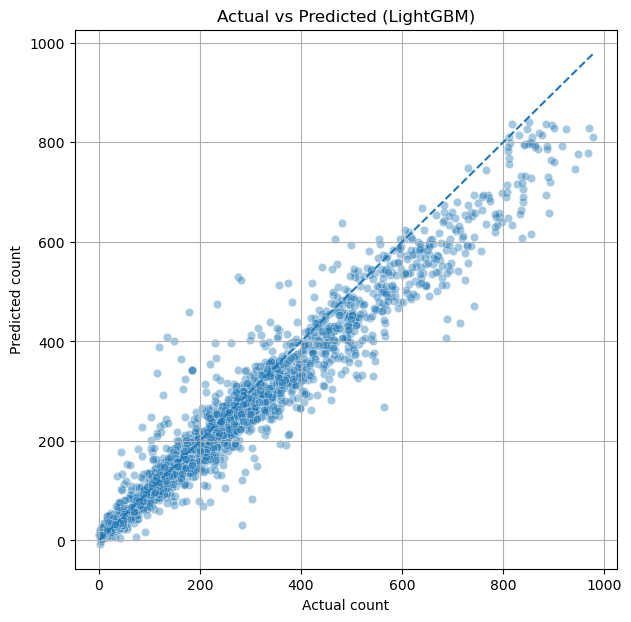

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

final_model = "LightGBM"
y_pred_final = preds[final_model]

plt.figure(figsize=(7,7))
sns.scatterplot(x=y_test, y=y_pred_final, alpha=0.4)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle='--')
plt.xlabel("Actual count")
plt.ylabel("Predicted count")
plt.title(f"Actual vs Predicted ({final_model})")
plt.grid(True)
plt.show()

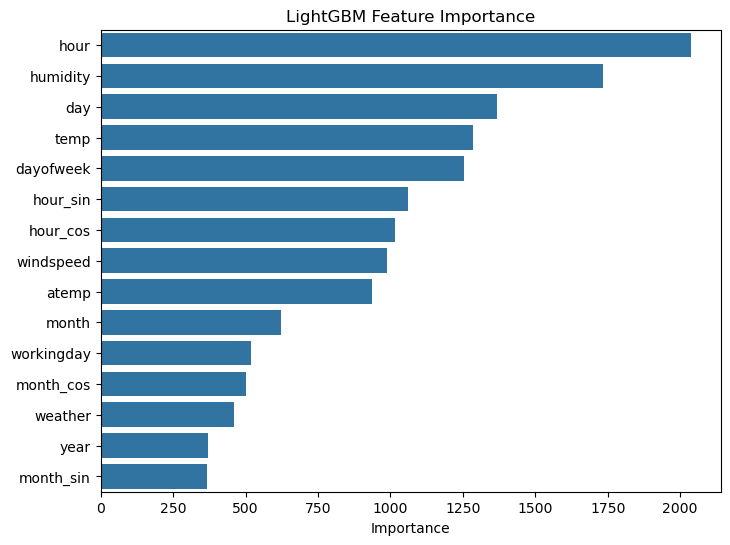

In [36]:
fi = pd.Series(lgbm.feature_importances_, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(x=fi.head(15).values, y=fi.head(15).index)
plt.title("LightGBM Feature Importance")
plt.xlabel("Importance")
plt.ylabel("")
plt.show()

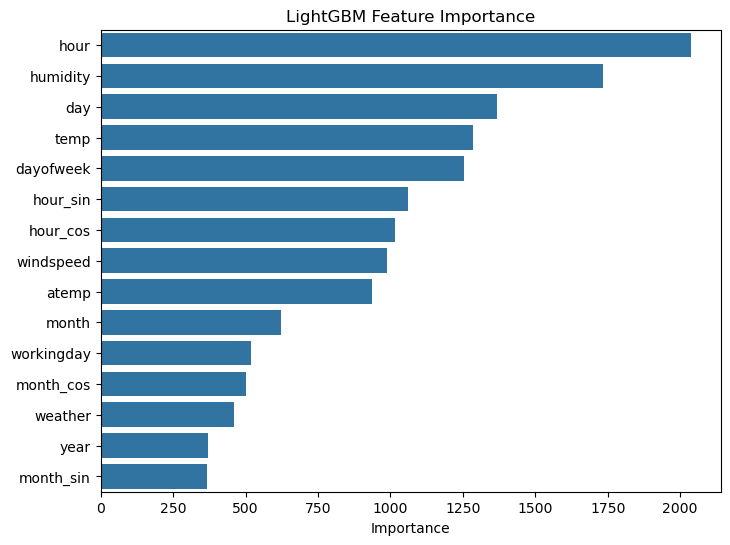

In [37]:
fi = pd.Series(lgbm.feature_importances_, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(x=fi.head(15).values, y=fi.head(15).index)
plt.title("LightGBM Feature Importance")
plt.xlabel("Importance")
plt.ylabel("")
plt.show()

RandomForest, HistGradientBoosting, XGBoost, LightGBM을 비교한 결과, LightGBM이 가장 우수한 성능을 보였다. <br>테스트셋 기준 MAE는 38.73, RMSE는 58.58, R²는 0.9275로 나타났으며, 이를 최종 예측 모델로 선정하였다.